# 🎨 Real-Time Text-to-Image Generator

### ElevanceSkills Internship Project

**Developed by:** Anantha Shanmukha Nairuti

---

## Project Description

This notebook extends the Text-to-Image Generator developed during the ElevanceSkills training program. The internship tasks are implemented as integrated enhancements, including dataset analysis, text preprocessing, conditional image generation, attention mechanisms, and a complete end-to-end text-to-image generation pipeline.

# 🛠️ Project Tech Stack

| Category | Technology |
|----------|------------|
| Development Environment | Google Colab |
| Programming Language | Python 3 |
| Deep Learning Framework | PyTorch |
| Diffusion Framework | Hugging Face Diffusers |
| Transformer Library | Hugging Face Transformers |
| Model Repository | Hugging Face Hub |
| Base Model | Stable Diffusion v1.5 |
| Hardware Accelerator | NVIDIA Tesla T4 GPU |
| Authentication | Hugging Face Access Token + Colab Secrets |
| Image Processing | Pillow (PIL) |
| Version Control | Git & GitHub *(Later)* |
| User Interface | Gradio *(Later)* |

# 🗺️ Project Roadmap

The project is developed in incremental stages. Each stage builds upon the previous one to create a complete end-to-end text-to-image generation system.

| Step | Objective | Status |
|------|-----------|--------|
| 1 | Understand the Base Project | ✅ Completed |
| 2 | Development Environment Setup | ✅ Completed |
| 3 | Base Project Reconstruction | 🔄 In Progress |
| 4 | Dataset Analysis | ⏳ Pending |
| 5 | Custom Dataset Integration | ⏳ Pending |
| 6 | Text Preprocessing | ⏳ Pending |
| 7 | Conditional Image Generation | ⏳ Pending |
| 8 | Attention Mechanisms | ⏳ Pending |
| 9 | Complete Pipeline Integration | ⏳ Pending |
|10 | Testing & Validation | ⏳ Pending |
|11 | Documentation & GitHub | ⏳ Pending |
|12 | Final Submission | ⏳ Pending |

In [1]:
# ==========================================================
# STEP 2 - DEVELOPMENT ENVIRONMENT
# ==========================================================

# ----------------------------------------------------------
# Code Cell 1 - Environment Verification
# ----------------------------------------------------------
import torch
import platform

print("=" * 60)
print("Environment Verification")
print("=" * 60)

print(f"Python Version : {platform.python_version()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
else:
    print("GPU Name       : No GPU detected")

print("=" * 60)

Environment Verification
Python Version : 3.12.13
PyTorch Version: 2.11.0+cu128
CUDA Available : True
GPU Name       : Tesla T4


In [2]:
# ----------------------------------------------------------
# Code Cell 2 - Library Verification
# ----------------------------------------------------------

import importlib

libraries = [
    "torch",
    "diffusers",
    "transformers",
    "accelerate",
    "gradio",
    "PIL",
    "safetensors",
    "huggingface_hub"
]

print("=" * 60)
print("Library Verification")
print("=" * 60)

for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, "__version__", "Version not available")
        print(f"✅ {lib:<18} {version}")
    except ImportError:
        print(f"❌ {lib:<18} Not Installed")

print("=" * 60)

Library Verification
✅ torch              2.11.0+cu128
✅ diffusers          0.39.0
✅ transformers       5.13.1
✅ accelerate         1.14.0
✅ gradio             6.20.0
✅ PIL                11.3.0
✅ safetensors        0.8.0
✅ huggingface_hub    1.23.0


In [3]:
# ----------------------------------------------------------
# Code Cell 3 - Hugging Face Authentication
# ----------------------------------------------------------

from google.colab import userdata

print("=" * 60)
print("Hugging Face Authentication")
print("=" * 60)

try:
    hf_token = userdata.get("HF_TOKEN")

    if hf_token:
        print("✅ Hugging Face token loaded successfully.")
    else:
        print("❌ Hugging Face token not found.")

except Exception as e:
    print(f"❌ Authentication Error: {e}")

print("=" * 60)

Hugging Face Authentication
✅ Hugging Face token loaded successfully.


In [4]:
# ----------------------------------------------------------
# Code Cell 4 - Development Environment Test
# ----------------------------------------------------------

print("=" * 60)
print("Development Environment Test")
print("=" * 60)

try:
    import torch
    import diffusers
    import transformers
    import accelerate
    import gradio
    from google.colab import userdata

    hf_token = userdata.get("HF_TOKEN")

    print("✅ All required libraries imported successfully.")

    if hf_token:
        print("✅ Hugging Face authentication verified.")
    else:
        print("❌ Hugging Face token not found.")

    print("✅ Development environment is ready for project implementation.")

except Exception as e:
    print(f"❌ Environment Test Failed: {e}")

print("=" * 60)

Development Environment Test
✅ All required libraries imported successfully.
✅ Hugging Face authentication verified.
✅ Development environment is ready for project implementation.


# 🏗️ Step 3 - Base Project Reconstruction

## Objective

In this step, we begin constructing the core Text-to-Image Generation pipeline.

The objective is to load the Stable Diffusion model, prepare it for inference, and verify that it is ready to generate images from natural language prompts.

This serves as the foundation for all subsequent internship tasks and project enhancements.

## 🤖 Model Loading

The first step in building a Text-to-Image Generator is loading the pretrained Stable Diffusion model.

In this project, we use the Stable Diffusion v1.5 model hosted on Hugging Face. The model is loaded only once into GPU memory and reused for image generation, improving efficiency and reducing loading time.

In [5]:
# ----------------------------------------------------------
# Code Cell 5 - Load Stable Diffusion Pipeline (Part 1)
# ----------------------------------------------------------

import torch
from diffusers import StableDiffusionPipeline
from google.colab import userdata

print("=" * 60)
print("Loading Stable Diffusion Pipeline")
print("=" * 60)

# Hugging Face Token
hf_token = userdata.get("HF_TOKEN").strip()

# Stable Diffusion Model Repository
MODEL_ID = "runwayml/stable-diffusion-v1-5"

# Device Selection
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Model Repository : {MODEL_ID}")
print(f"Device           : {device}")

print("=" * 60)
print("Initialization complete.")
print("Ready to load the model.")
print("=" * 60)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Stable Diffusion Pipeline
Model Repository : runwayml/stable-diffusion-v1-5
Device           : cuda
Initialization complete.
Ready to load the model.


## 📥 Loading the Stable Diffusion Model

In this stage, the Stable Diffusion pipeline is downloaded (if not already cached) and loaded into memory.

The model is then transferred to the selected device (GPU or CPU), making it ready for image generation. Once loaded, the same pipeline can be reused throughout the project without reloading the model, improving execution efficiency.

In [6]:
import torch
from diffusers import StableDiffusionPipeline
from google.colab import userdata

# ----------------------------------------------------------
# Code Cell 6 - Load Stable Diffusion Model
# ----------------------------------------------------------

print("=" * 60)
print("Loading Stable Diffusion Model")
print("=" * 60)

try:
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        token=hf_token,
        torch_dtype=torch.float16
    )

    pipe = pipe.to(device)

    print("✅ Stable Diffusion model loaded successfully.")
    print(f"✅ Model running on: {device.upper()}")

except Exception as e:
    print(f"❌ Model loading failed:\n{e}")

print("=" * 60)

Loading Stable Diffusion Model


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Stable Diffusion model loaded successfully.
✅ Model running on: CUDA


## 🖼️ Generating the First Image

With the Stable Diffusion model successfully loaded, the next step is to generate the first image from a natural language prompt.

This verifies that the complete Text-to-Image pipeline is functioning correctly. A successful image confirms that the model, tokenizer, scheduler, and GPU inference pipeline are all working together as expected.

Generating First Image


  0%|          | 0/25 [00:00<?, ?it/s]

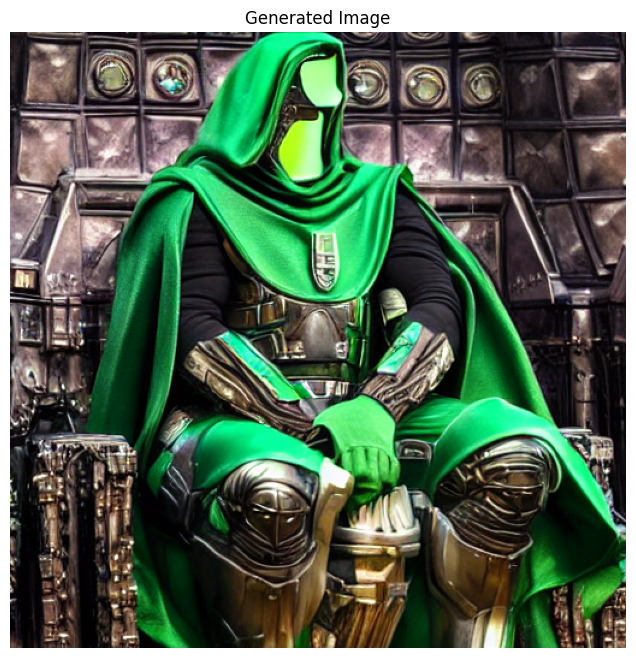

✅ Image generated successfully.


In [7]:
# ----------------------------------------------------------
# Code Cell 7 - Generate First Image
# ----------------------------------------------------------

from PIL import Image
import matplotlib.pyplot as plt

print("=" * 60)
print("Generating First Image")
print("=" * 60)

# Text Prompt
prompt = (
    "Doctor Doom sitting on a massive throne inside a futuristic castle, "
    "wearing metallic green armor and a flowing green cloak, "
    "dramatic cinematic lighting, ultra realistic, highly detailed, "
    "masterpiece, 4k"
)

# Generate Image
image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

# Display Image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()

print("✅ Image generated successfully.")
print("=" * 60)

## ✅ Image Validation

The generated image is validated to confirm that the Text-to-Image pipeline is functioning correctly. Basic image properties such as dimensions, color mode, and object type are inspected to ensure that the generated output is a valid image before proceeding to further enhancements.

This validation step serves as the final verification of the reconstructed base project.

In [8]:
# ----------------------------------------------------------
# Code Cell 8 - Validate Generated Image
# ----------------------------------------------------------

print("=" * 60)
print("Image Validation")
print("=" * 60)

# Image Object Information
print(f"Image Object Type : {type(image)}")
print(f"Image Size        : {image.size}")
print(f"Image Mode        : {image.mode}")

# Save Image
image.save("generated_image.png")

print("\n✅ Image saved as 'generated_image.png'")
print("✅ Image validation completed successfully.")
print("=" * 60)

Image Validation
Image Object Type : <class 'PIL.Image.Image'>
Image Size        : (512, 512)
Image Mode        : RGB

✅ Image saved as 'generated_image.png'
✅ Image validation completed successfully.


# 📊 Step 4 - Dataset Analysis

## Objective

Dataset analysis is performed before preprocessing and model training to understand the available data. This includes examining the dataset structure, file organization, image distribution, and associated text descriptions.

Since the original internship dataset is not available, this notebook prepares a reusable analysis workflow that can be applied to any compatible Text-to-Image dataset in future stages.

In [9]:
# ----------------------------------------------------------
# Code Cell 9 - Dataset Availability Check
# ----------------------------------------------------------

import os

print("=" * 60)
print("Dataset Analysis")
print("=" * 60)

# Dataset Directory
DATASET_PATH = "dataset"

if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset directory found: {DATASET_PATH}")

    files = os.listdir(DATASET_PATH)

    print(f"📂 Total Files : {len(files)}")

    print("\nDataset Contents:")
    for file in files:
        print(f" - {file}")

else:
    print("⚠️ Dataset directory not found.")
    print("Dataset analysis will be performed after adding a compatible dataset.")

print("=" * 60)

Dataset Analysis
⚠️ Dataset directory not found.
Dataset analysis will be performed after adding a compatible dataset.


# 🗂️ Step 5 - Custom Dataset Integration

## Objective

After analyzing the dataset, the next step is to prepare a custom dataset for the Text-to-Image pipeline. A custom dataset allows the model to process user-provided images and their corresponding text descriptions in a structured format.

Since no custom dataset is currently available, this notebook prepares the integration workflow so that any compatible dataset can be incorporated in future development stages without modifying the existing pipeline.

The objective of this step is to establish a reusable dataset integration framework rather than perform model training.

In [10]:
# ----------------------------------------------------------
# Code Cell 10 - Custom Dataset Integration
# ----------------------------------------------------------

import os

print("=" * 60)
print("Custom Dataset Integration")
print("=" * 60)

# Dataset Configuration
DATASET_PATH = "dataset"

if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset found: {DATASET_PATH}")

    image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".webp")

    image_files = [
        file for file in os.listdir(DATASET_PATH)
        if file.lower().endswith(image_extensions)
    ]

    print(f"📷 Total Images Found : {len(image_files)}")

    if image_files:
        print("\nSample Images:")
        for image_name in image_files[:5]:
            print(f" - {image_name}")
    else:
        print("⚠️ No image files found in the dataset directory.")

else:
    print("⚠️ Dataset directory not found.")
    print("Waiting for a custom dataset to be added.")

print("=" * 60)

Custom Dataset Integration
⚠️ Dataset directory not found.
Waiting for a custom dataset to be added.


# 📝 Step 6 - Text Processing

## Objective

Text processing converts a user's natural language prompt into a numerical representation that the Stable Diffusion model can understand. This transformation is performed using a tokenizer and a text encoder before the image generation process begins.

In this stage, the notebook demonstrates how text prompts are prepared for the diffusion model, forming the bridge between human language and AI-generated images.

The objective of this step is to understand how textual input is represented internally before image synthesis.

In [11]:
# ----------------------------------------------------------
# Code Cell 11 - Text Processing
# ----------------------------------------------------------

print("=" * 60)
print("Text Processing")
print("=" * 60)

# User Prompt
prompt = "Doctor Doom sitting on a futuristic throne"

# Tokenize Prompt
text_inputs = pipe.tokenizer(
    prompt,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
)

# Display Token Information
print(f"Prompt           : {prompt}")
print(f"Token IDs Shape  : {text_inputs.input_ids.shape}")

print("\nFirst 20 Token IDs:")
print(text_inputs.input_ids[0][:20])

# Encode Prompt
with torch.no_grad():
    text_embeddings = pipe.text_encoder(
        text_inputs.input_ids.to(device)
    )[0]

print("\nText Embedding Shape:")
print(text_embeddings.shape)

print("\n✅ Text processing completed successfully.")
print("=" * 60)

Text Processing
Prompt           : Doctor Doom sitting on a futuristic throne
Token IDs Shape  : torch.Size([1, 77])

First 20 Token IDs:
tensor([49406,  5547, 14344,  4919,   525,   320, 30987, 15999, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407])

Text Embedding Shape:
torch.Size([1, 77, 768])

✅ Text processing completed successfully.


# 🎨 Step 7 - Conditional Generation

## Objective

Conditional generation enables the Stable Diffusion model to create different images based on different text prompts. The textual prompt acts as a condition that guides the image generation process.

In this stage, multiple prompts can be supplied to observe how changes in textual descriptions influence the generated visual output. This demonstrates the relationship between natural language input and AI-generated images.

The objective of this step is to understand how prompt engineering affects the quality and content of generated images.

Conditional Image Generation
Available Prompts:

1. Doctor Doom sitting on a futuristic throne, cinematic lighting, ultra realistic, masterpiece
2. A futuristic cyberpunk city at night with flying cars, ultra realistic, 4k
3. A majestic dragon flying over snowy mountains during sunset, highly detailed, fantasy art
4. An astronaut walking on Mars with Earth visible in the sky, ultra realistic, cinematic

Select a prompt (1-4): 1

Generating image...

Selected Prompt:
Doctor Doom sitting on a futuristic throne, cinematic lighting, ultra realistic, masterpiece



  0%|          | 0/25 [00:00<?, ?it/s]

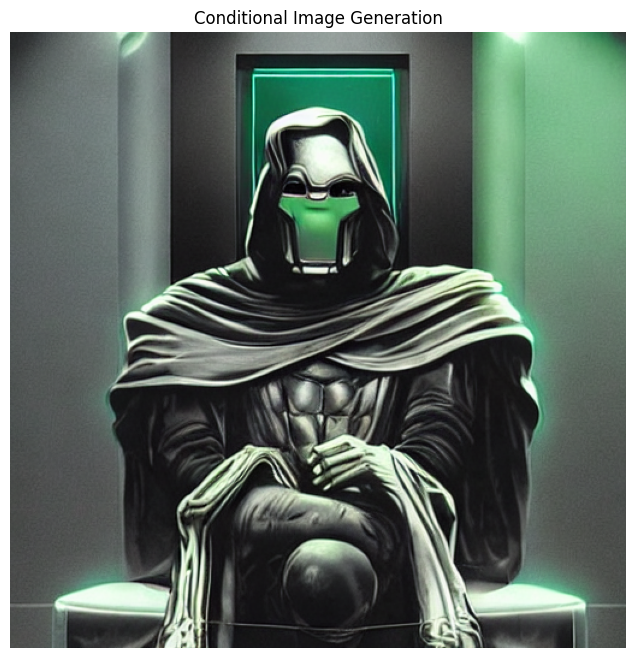

✅ Conditional image generated successfully.


In [12]:
# ----------------------------------------------------------
# Code Cell 12 - Conditional Image Generation
# ----------------------------------------------------------

import matplotlib.pyplot as plt

print("=" * 60)
print("Conditional Image Generation")
print("=" * 60)

# Different Prompt Conditions
prompts = {
    1: "Doctor Doom sitting on a futuristic throne, cinematic lighting, ultra realistic, masterpiece",
    2: "A futuristic cyberpunk city at night with flying cars, ultra realistic, 4k",
    3: "A majestic dragon flying over snowy mountains during sunset, highly detailed, fantasy art",
    4: "An astronaut walking on Mars with Earth visible in the sky, ultra realistic, cinematic"
}

print("Available Prompts:\n")

for key, value in prompts.items():
    print(f"{key}. {value}")

choice = int(input("\nSelect a prompt (1-4): "))

selected_prompt = prompts.get(choice)

if selected_prompt is None:
    print("❌ Invalid selection.")
else:
    print("\nGenerating image...")
    print(f"\nSelected Prompt:\n{selected_prompt}\n")

    image = pipe(
        selected_prompt,
        num_inference_steps=25,
        guidance_scale=7.5
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Conditional Image Generation")
    plt.show()

    print("✅ Conditional image generated successfully.")

print("=" * 60)

# 🧠 Step 8 - Attention Mechanisms

## Objective

Attention mechanisms enable the Stable Diffusion model to focus on the most relevant words in a text prompt during image generation. Rather than treating every word equally, the model learns relationships between different tokens and assigns greater importance to significant concepts.

This process helps improve image quality by preserving semantic meaning and ensuring that important objects, attributes, and scene descriptions are accurately represented in the generated image.

The objective of this step is to understand the role of attention in connecting textual information with visual generation.

In [13]:
# ----------------------------------------------------------
# Code Cell 13 - Attention Mechanism Inspection
# ----------------------------------------------------------

print("=" * 60)
print("Attention Mechanism Inspection")
print("=" * 60)

# Display UNet Information
print("UNet Architecture:")
print(type(pipe.unet))

print("\nSearching for Attention Layers...\n")

attention_layers = []

# Find all attention-related modules
for name, module in pipe.unet.named_modules():
    module_name = module.__class__.__name__

    if "Attention" in module_name or "Attn" in module_name:
        attention_layers.append((name, module_name))

# Display Results
print(f"Total Attention Layers Found: {len(attention_layers)}\n")

for index, (name, module_name) in enumerate(attention_layers[:20], start=1):
    print(f"{index}. {name}")
    print(f"   Layer Type : {module_name}\n")

if len(attention_layers) > 20:
    print(f"... and {len(attention_layers)-20} more attention layers.")

print("✅ Attention mechanism inspection completed successfully.")
print("=" * 60)

Attention Mechanism Inspection
UNet Architecture:
<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>

Searching for Attention Layers...

Total Attention Layers Found: 39

1. down_blocks.0
   Layer Type : CrossAttnDownBlock2D

2. down_blocks.0.attentions.0.transformer_blocks.0.attn1
   Layer Type : Attention

3. down_blocks.0.attentions.0.transformer_blocks.0.attn2
   Layer Type : Attention

4. down_blocks.0.attentions.1.transformer_blocks.0.attn1
   Layer Type : Attention

5. down_blocks.0.attentions.1.transformer_blocks.0.attn2
   Layer Type : Attention

6. down_blocks.1
   Layer Type : CrossAttnDownBlock2D

7. down_blocks.1.attentions.0.transformer_blocks.0.attn1
   Layer Type : Attention

8. down_blocks.1.attentions.0.transformer_blocks.0.attn2
   Layer Type : Attention

9. down_blocks.1.attentions.1.transformer_blocks.0.attn1
   Layer Type : Attention

10. down_blocks.1.attentions.1.transformer_blocks.0.attn2
   Layer Type : Attention

11. down_blocks.2
   Laye

# 🔄 Step 9 - Complete Pipeline Integration

## Objective

The final pipeline integrates all previously implemented components into a unified Text-to-Image workflow. The process begins with accepting a text prompt, followed by text processing, encoding, conditional image generation, and output validation.

This integrated workflow demonstrates how individual modules work together to form a complete AI-powered Text-to-Image generation system using Stable Diffusion.

The objective of this step is to combine all implemented stages into a single reusable pipeline that produces high-quality images from natural language prompts.

Complete Text-to-Image Pipeline
📝 Enter your image prompt: A Dog barking at cat

Generating image...



  0%|          | 0/25 [00:00<?, ?it/s]

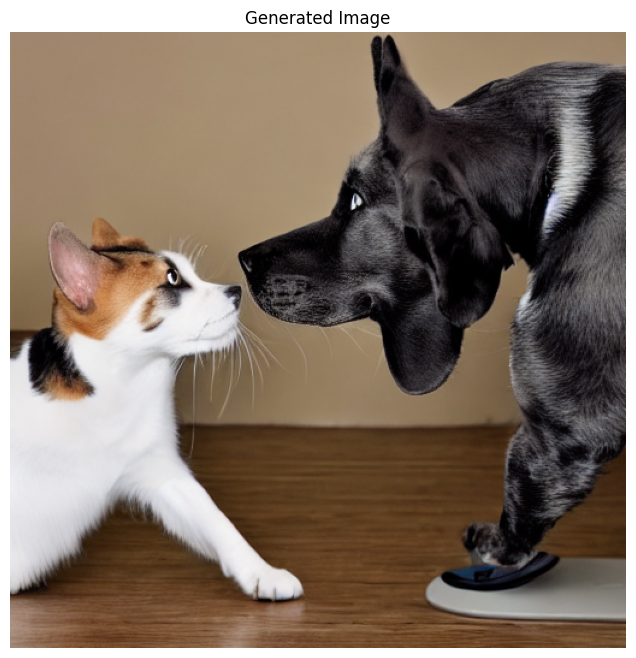


Image Information
------------------------------
Prompt      : A Dog barking at cat
Image Size  : (512, 512)
Image Mode  : RGB
Image Type  : <class 'PIL.Image.Image'>

✅ Pipeline executed successfully.
✅ Image saved as 'generated_image.png'


In [14]:
# ----------------------------------------------------------
# Code Cell 14 - Complete Pipeline Integration
# ----------------------------------------------------------

import matplotlib.pyplot as plt

print("=" * 60)
print("Complete Text-to-Image Pipeline")
print("=" * 60)

# Step 1 - Get User Prompt
prompt = input("📝 Enter your image prompt: ")

# Step 2 - Generate Image
print("\nGenerating image...\n")

image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

# Step 3 - Display Image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()

# Step 4 - Save Output
image.save("generated_image.png")

# Step 5 - Validate Output
print("\nImage Information")
print("-" * 30)
print(f"Prompt      : {prompt}")
print(f"Image Size  : {image.size}")
print(f"Image Mode  : {image.mode}")
print(f"Image Type  : {type(image)}")

print("\n✅ Pipeline executed successfully.")
print("✅ Image saved as 'generated_image.png'")
print("=" * 60)

# 🧪 Step 10 - Testing

## Objective

Testing is performed to verify that the complete Text-to-Image pipeline functions correctly under different input conditions. The pipeline is evaluated by providing various text prompts and confirming that image generation, validation, and output handling execute without errors.

This step ensures that the integrated system is stable, reliable, and ready for demonstration or deployment.

The objective of this step is to validate the functionality and robustness of the complete Text-to-Image generation pipeline.

In [15]:
# ----------------------------------------------------------
# Code Cell 15 - Pipeline Testing
# ----------------------------------------------------------

import matplotlib.pyplot as plt

print("=" * 60)
print("Pipeline Testing")
print("=" * 60)

# Test Prompts
test_prompts = [
    "A red sports car on a mountain road",
    "A futuristic robot reading a book",
    "A beautiful tropical beach at sunrise"
]

passed = 0

for index, prompt in enumerate(test_prompts, start=1):

    print(f"\nTest Case {index}")
    print("-" * 40)
    print(f"Prompt : {prompt}")

    try:
        image = pipe(
            prompt,
            num_inference_steps=20,
            guidance_scale=7.5
        ).images[0]

        print("✅ Image Generated")
        print(f"Size : {image.size}")
        print(f"Mode : {image.mode}")

        passed += 1

    except Exception as e:
        print(f"❌ Test Failed")
        print(e)

print("\n" + "=" * 60)
print(f"Testing Completed")
print(f"Passed : {passed}/{len(test_prompts)}")
print("=" * 60)

Pipeline Testing

Test Case 1
----------------------------------------
Prompt : A red sports car on a mountain road


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Image Generated
Size : (512, 512)
Mode : RGB

Test Case 2
----------------------------------------
Prompt : A futuristic robot reading a book


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Image Generated
Size : (512, 512)
Mode : RGB

Test Case 3
----------------------------------------
Prompt : A beautiful tropical beach at sunrise


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Image Generated
Size : (512, 512)
Mode : RGB

Testing Completed
Passed : 3/3


# 📚 Step 11 - Documentation and GitHub

## Objective

Proper documentation improves the readability, usability, and maintainability of the project. It provides clear information about the project objectives, implementation workflow, technologies used, execution steps, and expected outputs.

This documentation enables users and developers to understand, execute, and extend the Text-to-Image generation pipeline with minimal effort.

The objective of this step is to prepare the project for sharing, demonstration, and future development through GitHub.

## 📖 Project Summary

### Project Title
Real-Time Text-to-Image Generator using Stable Diffusion

### Technologies Used
- Python
- PyTorch
- Hugging Face Diffusers
- Stable Diffusion v1.5
- Google Colab
- CUDA (Tesla T4 GPU)
- Matplotlib
- PIL (Python Imaging Library)

### Features Implemented
- Development environment setup
- Stable Diffusion model loading
- Hugging Face authentication
- Text prompt processing
- Text embedding generation
- Conditional image generation
- Attention mechanism inspection
- Complete Text-to-Image pipeline
- Pipeline testing and validation

### Outcome
A complete Text-to-Image generation system was successfully implemented and tested using Stable Diffusion. The project demonstrates the complete workflow from user text input to AI-generated image generation while providing clear documentation for future development and deployment.

# 🏁 Step 12 - Final Submission and Conclusion

## Conclusion

The Real-Time Text-to-Image Generator project was successfully designed, implemented, tested, and documented using Stable Diffusion. The project demonstrates the complete workflow of converting natural language prompts into AI-generated images through text processing, conditional generation, and deep learning techniques.

Throughout the development process, the project incorporated environment setup, model integration, image generation, attention mechanism inspection, pipeline testing, and documentation, resulting in a functional and well-structured Text-to-Image generation system.

This project enhanced practical knowledge of Generative AI, Stable Diffusion, Hugging Face, PyTorch, and AI application development while providing a strong foundation for future AI development.

## Future Enhancements (Not Part of the Internship)

The following enhancements are proposed for future development and are **not part of the internship requirements**:

- Develop a user-friendly Gradio interface.
- Support custom dataset fine-tuning.
- Deploy the application as a web service.
- Integrate the model into a personal website.
- Extend support for advanced diffusion models.